# Análisis Exploratorio de Datos (EDA) y Feature Engineering

Este notebook te guiará paso a paso a través de un análisis completo de un dataset, aplicando técnicas de limpieza, visualización, creación de características y selección. Usaremos el dataset **Titanic** por su riqueza y facilidad de interpretación.

**Objetivo:** Proporcionar un arsenal de técnicas que puedas aplicar a cualquier dataset genérico.

In [1]:
# ============================================================
# 1. CONFIGURACIÓN INICIAL: IMPORTAR LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Para visualizaciones más interactivas (opcional)
# import plotly.express as px

# Para análisis estadístico
from scipy import stats

# Para feature engineering y modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, RFE

# Configuración de estilo
sns.set_style('whitegrid')
%matplotlib inline

## 2. CARGA DEL DATASET
Utilizaremos el dataset Titanic incluido en Seaborn. Este dataset contiene información sobre los pasajeros y si sobrevivieron o no.

In [2]:
# Cargar datos
df = sns.load_dataset('titanic')
print('Dataset cargado correctamente')
print(f'Dimensiones: {df.shape}')
df.head()

Dataset cargado correctamente
Dimensiones: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. INSPECCIÓN INICIAL
Antes de nada, debemos conocer la estructura, tipos de datos y estadísticas básicas.

In [3]:
# Información general: tipos y nulos
df.info()

# Estadísticas descriptivas (incluyendo categóricas)
df.describe(include='all').T

# Ver columnas
print('\nColumnas:', df.columns.tolist())

# Ejemplo de datos
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Columnas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'emba

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
356,1,1,female,22.0,0,1,55.0000,S,First,woman,False,E,Southampton,yes,False
636,0,3,male,32.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
146,1,3,male,27.0,0,0,7.7958,S,Third,man,True,NaN,Southampton,yes,True
337,1,1,female,41.0,0,0,134.5000,C,First,woman,False,E,Cherbourg,yes,True


## 4. LIMPIEZA DE DATOS

### 4.1. Valores faltantes
Identificamos y tratamos los nulos.

In [4]:
# Porcentaje de nulos por columna
nulls = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje': null_pct})
null_df[null_df['Nulos'] > 0].sort_values('Porcentaje', ascending=False)

,Nulos,Porcentaje
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


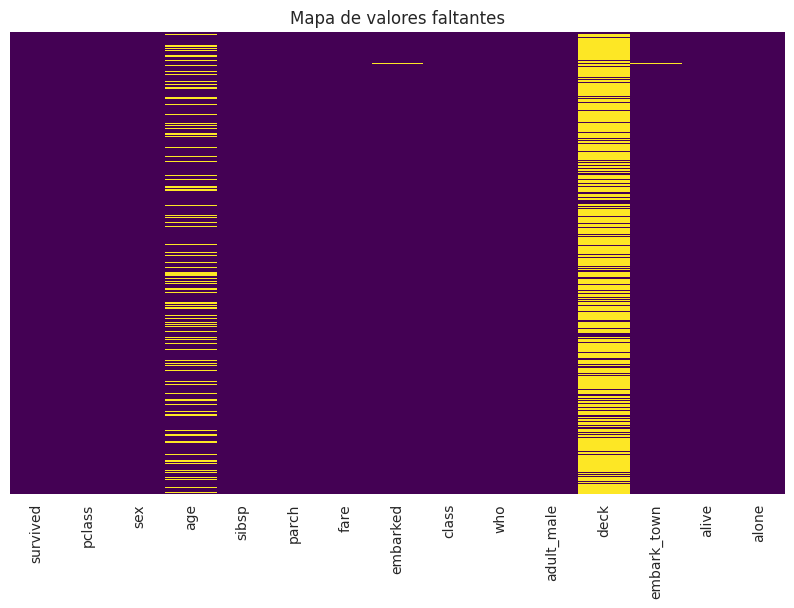

In [5]:
# Visualizar nulos con un heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de valores faltantes')
plt.show()

In [6]:
# Estrategias de imputación:
# - 'deck' tiene demasiados nulos (~77%) -> eliminamos la columna
# - 'age' tiene ~20% nulos -> imputamos con la mediana
# - 'embarked' tiene 2 nulos -> imputamos con la moda
# - 'embark_town' es redundante con 'embarked' -> la eliminamos

df.drop(columns=['deck', 'embark_town'], inplace=True)

# Imputar edad con la mediana
df['age'].fillna(df['age'].median(), inplace=True)

# Imputar embarked con la moda
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Opcional: crear una bandera de missing en edad (por si el hecho de que falte tiene poder predictivo)
df['age_missing'] = df['age'].isnull().astype(int)  # ya no hay nulos, pero lo dejamos como ejemplo

# Verificar que ya no hay nulos
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


### 4.2. Valores duplicados
Comprobamos si hay filas duplicadas.

In [7]:
print(f'Número de duplicados: {df.duplicated().sum()}')
# Si hubiera, podríamos eliminarlos con df.drop_duplicates(inplace=True)

Número de duplicados: 116


### 4.3. Errores de tipo de dato
Aseguramos que las variables tengan el tipo adecuado.

In [8]:
# Convertir a categóricas las que son objetos
categorical_cols = ['sex', 'embarked', 'class', 'who', 'adult_male', 'alive', 'alone']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 'pclass' es ordinal, lo dejamos como int pero podría ser category
df['pclass'] = df['pclass'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    category
 2   sex          891 non-null    category
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    category
 10  adult_male   891 non-null    category
 11  alive        891 non-null    category
 12  alone        891 non-null    category
 13  age_missing  891 non-null    int64   
dtypes: category(8), float64(2), int64(4)
memory usage: 49.8 KB


### 4.4. Valores atípicos (outliers)
Detectamos outliers en variables numéricas usando boxplots y el método IQR.

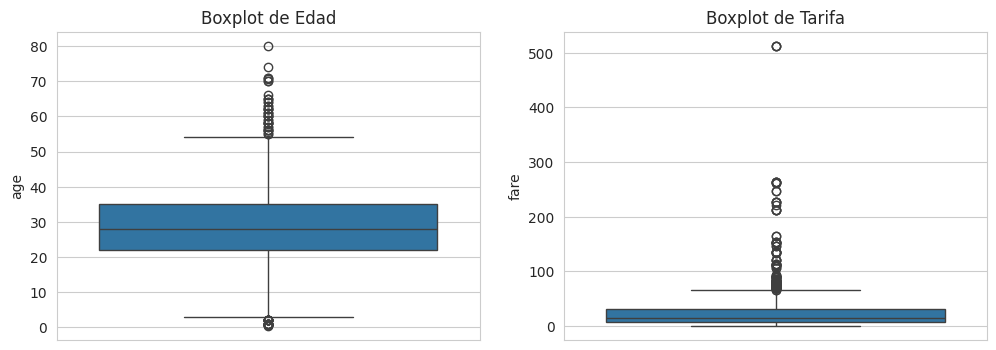

In [9]:
# Visualizar distribuciones con boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, y='age', ax=axes[0])
axes[0].set_title('Boxplot de Edad')
sns.boxplot(data=df, y='fare', ax=axes[1])
axes[1].set_title('Boxplot de Tarifa')
plt.show()

In [10]:
# Función para detectar outliers usando IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers_age, low_age, up_age = detect_outliers_iqr(df, 'age')
outliers_fare, low_fare, up_fare = detect_outliers_iqr(df, 'fare')

print(f'Outliers en edad: {len(outliers_age)} ({len(outliers_age)/len(df)*100:.2f}%)')
print(f'Outliers en tarifa: {len(outliers_fare)} ({len(outliers_fare)/len(df)*100:.2f}%)')

# Estrategia: no eliminamos, pero podríamos limitarlos (winsorizar) si afectan al modelo.
# Por ahora los dejamos, pero más adelante podríamos transformar la variable.

Outliers en edad: 66 (7.41%)
Outliers en tarifa: 116 (13.02%)


## 5. ANÁLISIS UNIVARIANTE

### 5.1. Variables numéricas

In [11]:
# Seleccionar numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Variables numéricas:', num_cols)

# Estadísticas de forma
for col in num_cols:
    print(f'\n{col}:')
    print(f'  Media: {df[col].mean():.2f}')
    print(f'  Mediana: {df[col].median():.2f}')
    print(f'  Desviación: {df[col].std():.2f}')
    print(f'  Asimetría (skew): {df[col].skew():.2f}')
    print(f'  Curtosis: {df[col].kurtosis():.2f}')

Variables numéricas: ['survived', 'age', 'sibsp', 'parch', 'fare', 'age_missing']

survived:
  Media: 0.38
  Mediana: 0.00
  Desviación: 0.49
  Asimetría (skew): 0.48
  Curtosis: -1.78

age:
  Media: 29.36
  Mediana: 28.00
  Desviación: 13.02
  Asimetría (skew): 0.51
  Curtosis: 0.99

sibsp:
  Media: 0.52
  Mediana: 0.00
  Desviación: 1.10
  Asimetría (skew): 3.70
  Curtosis: 17.88

parch:
  Media: 0.38
  Mediana: 0.00
  Desviación: 0.81
  Asimetría (skew): 2.75
  Curtosis: 9.78

fare:
  Media: 32.20
  Mediana: 14.45
  Desviación: 49.69
  Asimetría (skew): 4.79
  Curtosis: 33.40

age_missing:
  Media: 0.00
  Mediana: 0.00
  Desviación: 0.00
  Asimetría (skew): 0.00
  Curtosis: 0.00


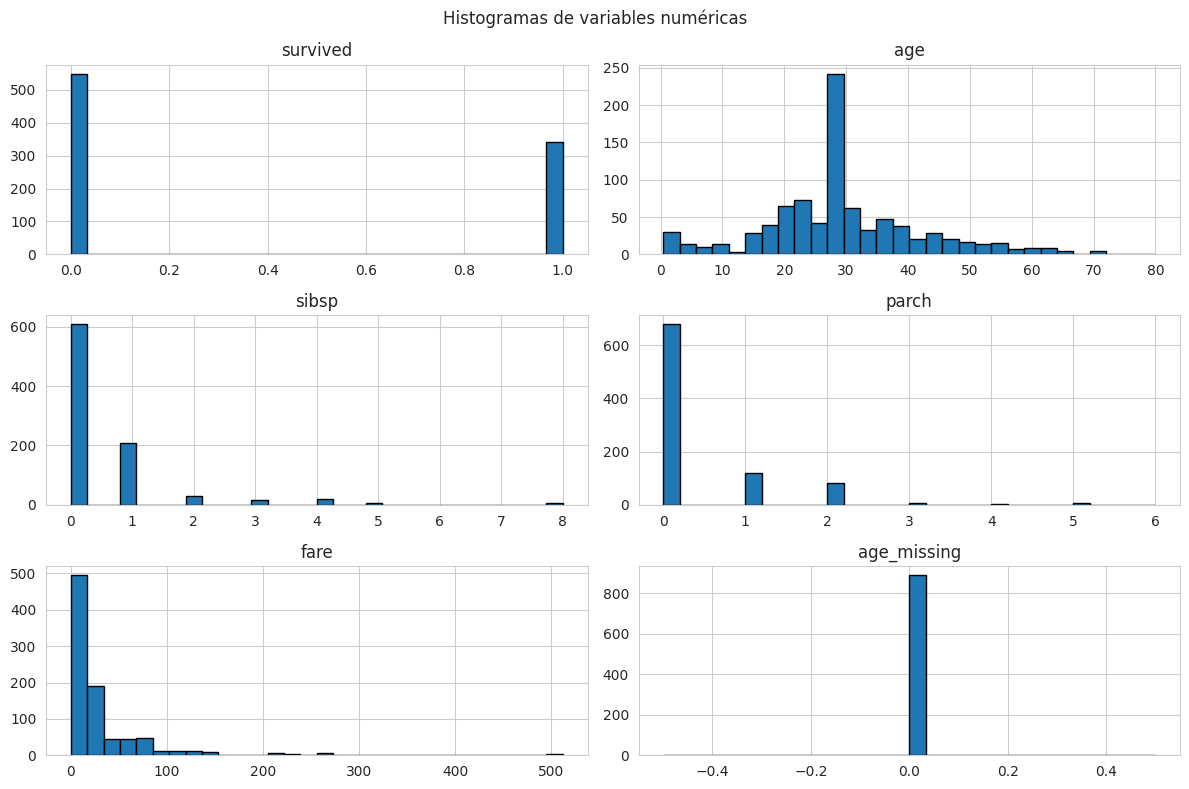

In [12]:
# Histogramas
df[num_cols].hist(bins=30, figsize=(12, 8), edgecolor='black')
plt.suptitle('Histogramas de variables numéricas')
plt.tight_layout()
plt.show()

### 5.2. Variables categóricas

Variables categóricas: ['pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'alive', 'alone']

--- pclass ---
pclass
3    491
1    216
2    184
Name: count, dtype: int64
Moda: 3


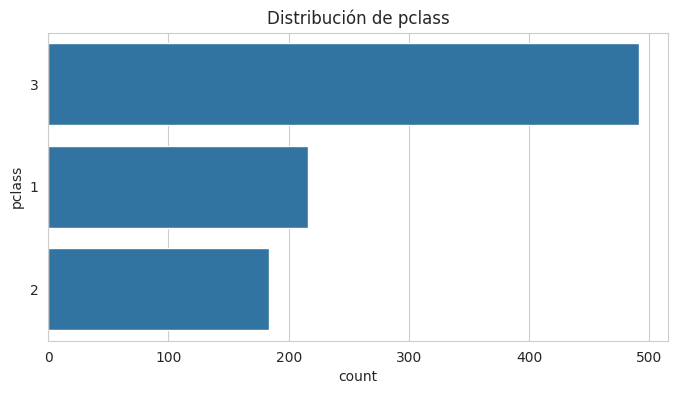


--- sex ---
sex
male      577
female    314
Name: count, dtype: int64
Moda: male


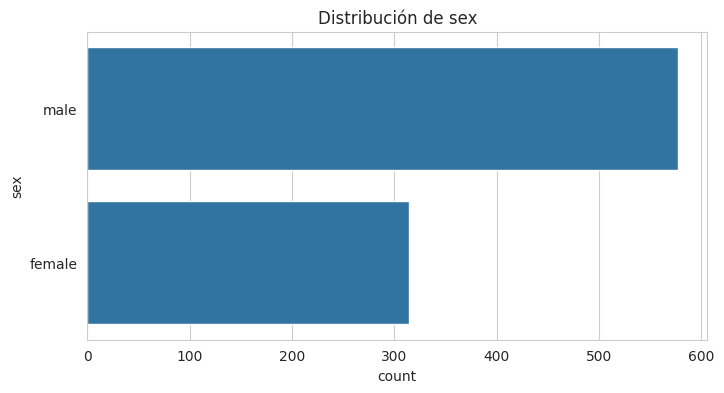


--- embarked ---
embarked
S    646
C    168
Q     77
Name: count, dtype: int64
Moda: S


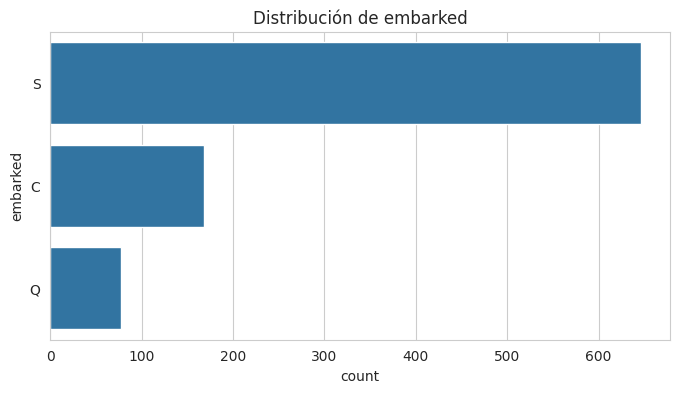


--- class ---
class
Third     491
First     216
Second    184
Name: count, dtype: int64
Moda: Third


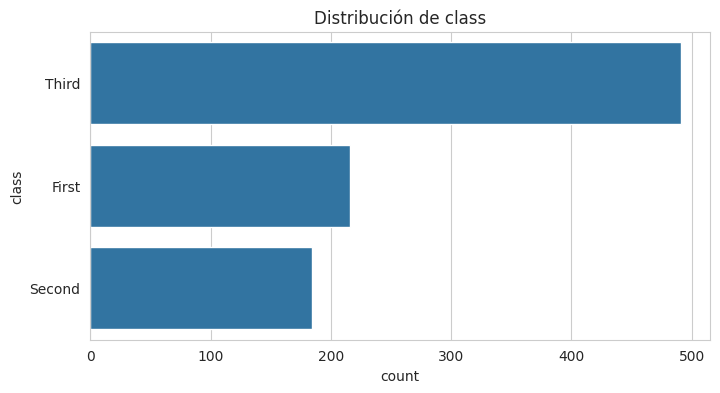


--- who ---
who
man      537
woman    271
child     83
Name: count, dtype: int64
Moda: man


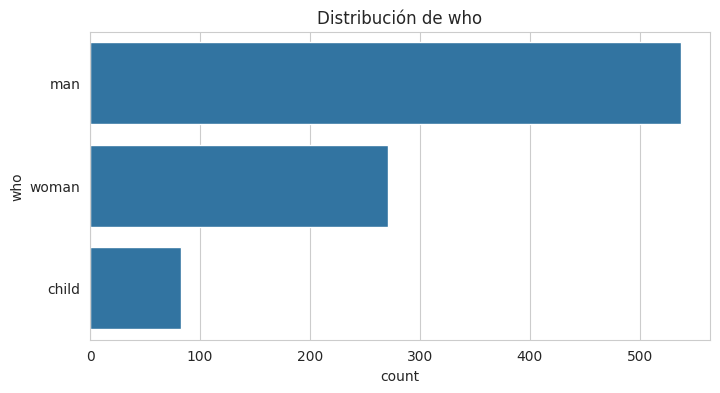


--- adult_male ---
adult_male
True     537
False    354
Name: count, dtype: int64
Moda: True


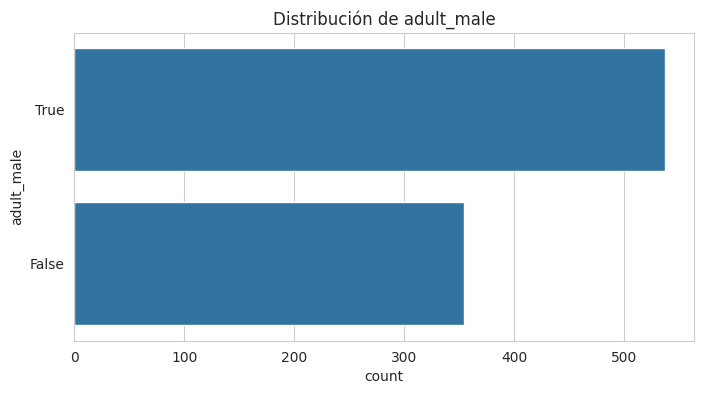


--- alive ---
alive
no     549
yes    342
Name: count, dtype: int64
Moda: no


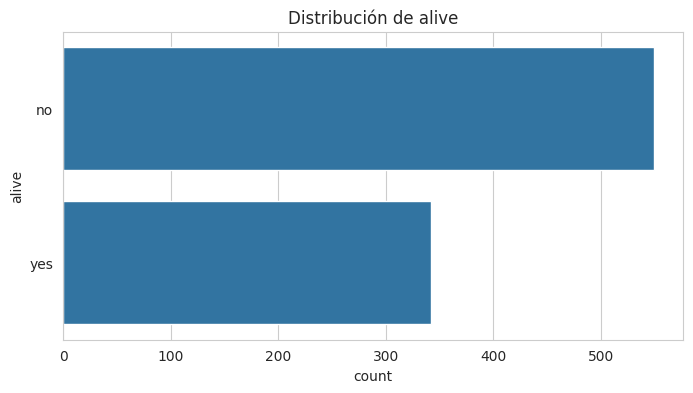


--- alone ---
alone
True     537
False    354
Name: count, dtype: int64
Moda: True


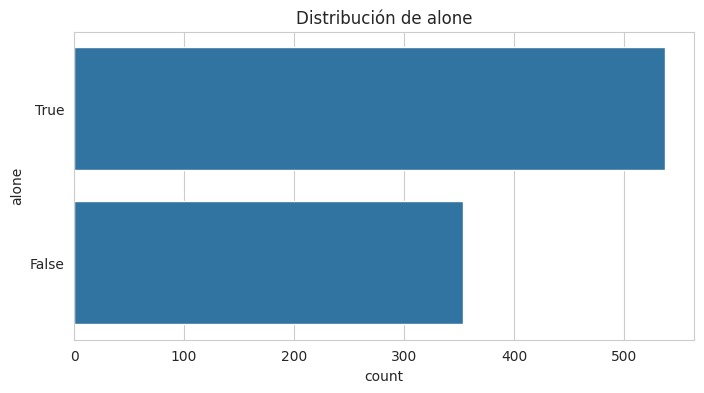

In [13]:
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
print('Variables categóricas:', cat_cols)

for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())
    print(f'Moda: {df[col].mode()[0]}')
    # Gráfico de barras
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.show()

## 6. ANÁLISIS MULTIVARIANTE

### 6.1. Relaciones entre numéricas (correlación)

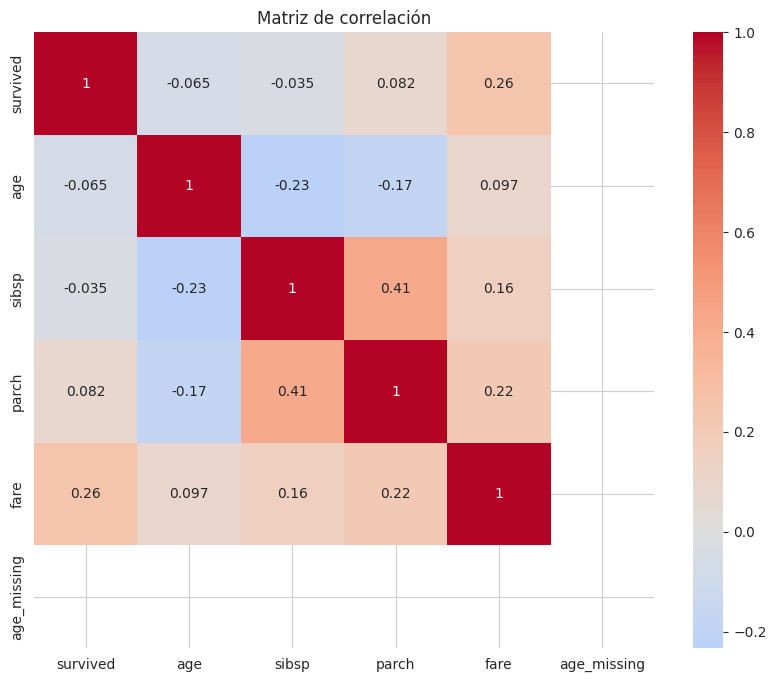

In [14]:
# Matriz de correlación (solo numéricas)
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

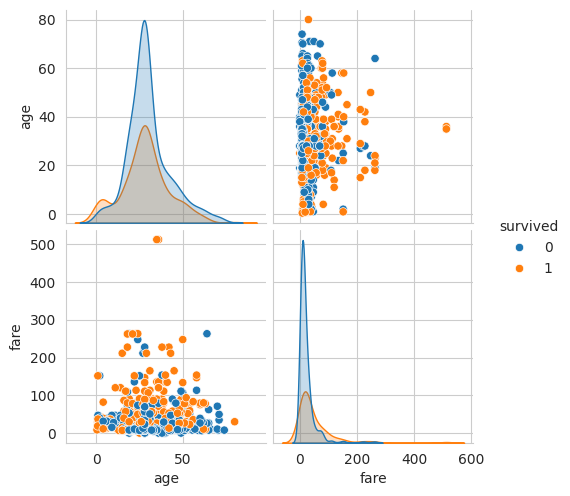

In [15]:
# Pairplot (cuidado con muchas variables, podemos seleccionar algunas)
sns.pairplot(df[['survived', 'age', 'fare', 'pclass']], hue='survived', diag_kind='kde')
plt.show()

### 6.2. Numérica vs Categórica

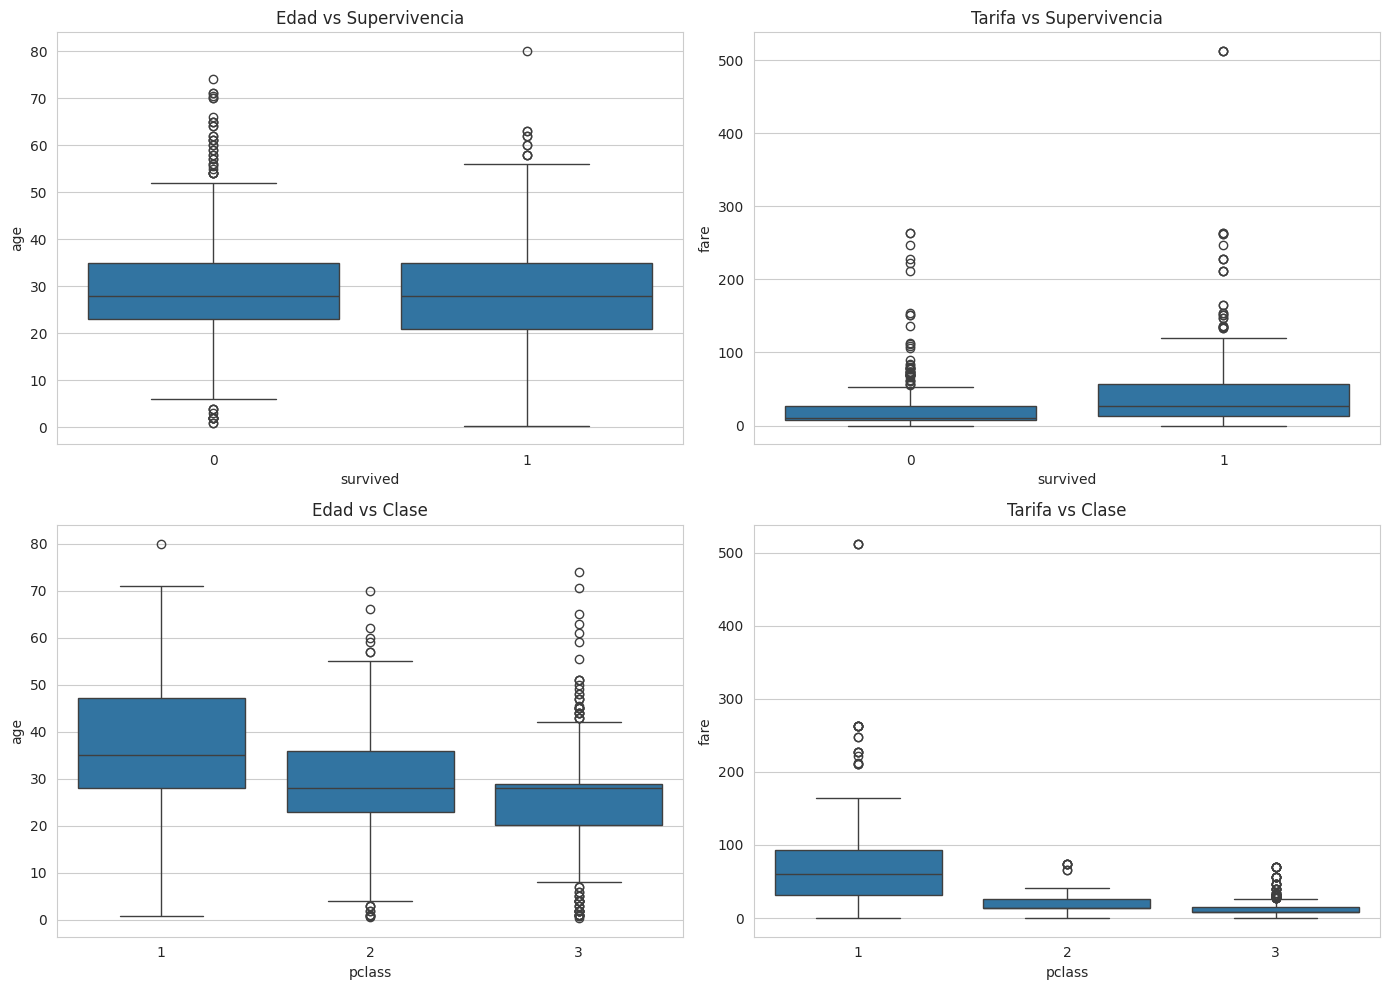

In [16]:
# Boxplots de edad y tarifa segmentados por supervivencia y clase
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='survived', y='age', ax=axes[0,0])
axes[0,0].set_title('Edad vs Supervivencia')

sns.boxplot(data=df, x='survived', y='fare', ax=axes[0,1])
axes[0,1].set_title('Tarifa vs Supervivencia')

sns.boxplot(data=df, x='pclass', y='age', ax=axes[1,0])
axes[1,0].set_title('Edad vs Clase')

sns.boxplot(data=df, x='pclass', y='fare', ax=axes[1,1])
axes[1,1].set_title('Tarifa vs Clase')

plt.tight_layout()
plt.show()

### 6.3. Categórica vs Categórica

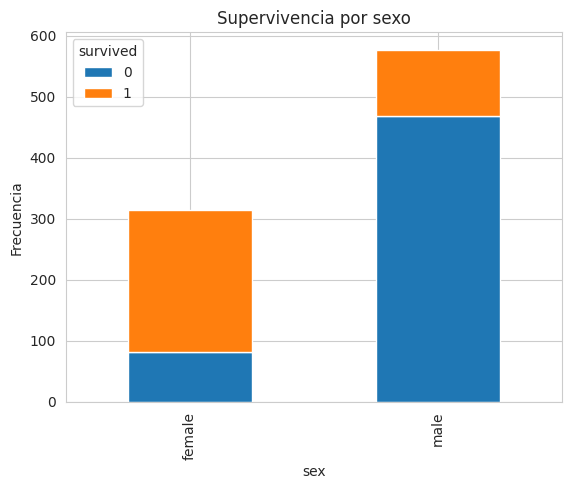

In [17]:
# Tabla de contingencia: sexo vs supervivencia
pd.crosstab(df['sex'], df['survived'], margins=True, normalize='index')

# Gráfico de barras apiladas
pd.crosstab(df['sex'], df['survived']).plot(kind='bar', stacked=True)
plt.title('Supervivencia por sexo')
plt.ylabel('Frecuencia')
plt.show()

In [18]:
# Test Chi-cuadrado para independencia entre sexo y supervivencia
from scipy.stats import chi2_contingency
table = pd.crosstab(df['sex'], df['survived'])
chi2, p, dof, expected = chi2_contingency(table)
print(f'Chi2: {chi2:.2f}, p-valor: {p:.5f}')

Chi2: 260.72, p-valor: 0.00000


## 7. FEATURE ENGINEERING

### 7.1. Creación de nuevas variables
A partir del conocimiento del dominio, generamos características que puedan ayudar al modelo.

In [20]:
# Tamaño de la familia (incluyendo al propio pasajero)
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Indicador de si viaja solo
df['is_alone'] = (df['family_size'] == 1).astype(int)

# Título a partir del nombre (extraemos usando expresiones regulares)
# df['title'] = df['name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# df['title'].value_counts()

# Agrupar títulos poco frecuentes
# rare_titles = ['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
# df['title'] = df['title'].replace(rare_titles, 'Rare')
# df['title'] = df['title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})

# Categorías de edad
bins = [0, 12, 18, 35, 60, 100]
labels = ['Niño', 'Adolescente', 'Adulto_joven', 'Adulto', 'Mayor']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Categorías de tarifa (por cuantiles)
df['fare_group'] = pd.qcut(df['fare'], q=4, labels=['Bajo', 'Medio_bajo', 'Medio_alto', 'Alto'])

# Indicador de tener cabina (aunque eliminamos deck, podemos crear una variable que indique si tenía cabina asignada)
# (Originalmente 'deck' tenía valores, pero ya la eliminamos; en su lugar usamos una columna temporal)
# Para no perder información, podríamos haber conservado la existencia de cabina.
# Como ya eliminamos deck, simulamos: si el nombre tiene algo... mejor no.
# Dejamos esto como ejemplo de creación de bandera a partir de nulos.
# En un caso real, podrías tener una columna 'cabin' con strings o NaN. Aquí ya no la tenemos.

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone,age_missing,family_size,is_alone,age_group,fare_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False,0,2,0,Adulto_joven,Bajo
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False,0,2,0,Adulto,Alto
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True,0,1,1,Adulto_joven,Medio_bajo
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False,0,2,0,Adulto_joven,Alto
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True,0,1,1,Adulto_joven,Medio_bajo


### 7.2. Codificación de variables categóricas
Convertimos las categóricas a formato numérico para que los modelos puedan procesarlas.

In [22]:
# Identificamos las nuevas categóricas
new_cat = ['age_group', 'fare_group'] # 'title' removed as it's not created
for col in new_cat:
    df[col] = df[col].astype('category')

# One-Hot Encoding para nominales sin orden
df_encoded = pd.get_dummies(df, columns=['sex', 'embarked', 'age_group', 'fare_group'], drop_first=True) # 'title' removed

# Label Encoding para ordinales (pclass tiene orden, pero ya es numérico; igual para is_alone, family_size)
# 'class' es redundante con pclass, la eliminamos
df_encoded.drop(columns=['class', 'who', 'adult_male', 'alive', 'alone'], inplace=True)

# Ver nuevas columnas
print(df_encoded.shape)
df_encoded.columns.tolist()

(891, 19)


['survived',
 'pclass',
 'age',
 'sibsp',
 'parch',
 'fare',
 'age_missing',
 'family_size',
 'is_alone',
 'sex_male',
 'embarked_Q',
 'embarked_S',
 'age_group_Adolescente',
 'age_group_Adulto_joven',
 'age_group_Adulto',
 'age_group_Mayor',
 'fare_group_Medio_bajo',
 'fare_group_Medio_alto',
 'fare_group_Alto']

### 7.3. Escalado de variables numéricas
Normalizamos las características numéricas para que tengan media 0 y desviación 1.

In [23]:
# Seleccionar columnas numéricas a escalar (excluyendo binarias y target)
num_to_scale = ['age', 'fare', 'family_size']
scaler = StandardScaler()
df_encoded[num_to_scale] = scaler.fit_transform(df_encoded[num_to_scale])

# Ver resultado
df_encoded[num_to_scale].describe()

,age,fare,family_size
count,8.910000e+02,8.910000e+02,8.910000e+02
mean,2.272780e-16,3.987333e-18,-2.392400e-17
std,1.000562e+00,1.000562e+00,1.000562e+00
min,-2.224156e+00,-6.484217e-01,-5.609748e-01
25%,-5.657365e-01,-4.891482e-01,-5.609748e-01
50%,-1.046374e-01,-3.573909e-01,-5.609748e-01
75%,4.333115e-01,-2.424635e-02,5.915988e-02
max,3.891554e+00,9.667167e+00,5.640372e+00


## 8. FEATURE SELECTION

### 8.1. Eliminar variables con varianza baja o correlación alta

In [25]:
# Calcular varianza de las numéricas (las escaladas tienen varianza 1, las dummies tienen varianza p(1-p))
variances = df_encoded.var(numeric_only=True)
low_variance = variances[variances < 0.01].index.tolist()
print(f'Variables con varianza < 0.01: {low_variance}')
# Podríamos eliminarlas, pero algunas dummies pueden tener varianza baja y ser útiles.

# Correlación alta entre features
corr_matrix = df_encoded.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper.columns if any(upper[column] > 0.8)]
print(f'Variables con correlación > 0.8 con otra: {high_corr}')
# Por ejemplo, podríamos eliminar una de cada par altamente correlacionado.

Variables con varianza < 0.01: ['age_missing']
Variables con correlación > 0.8 con otra: ['family_size']


### 8.2. Importancia de características con un modelo

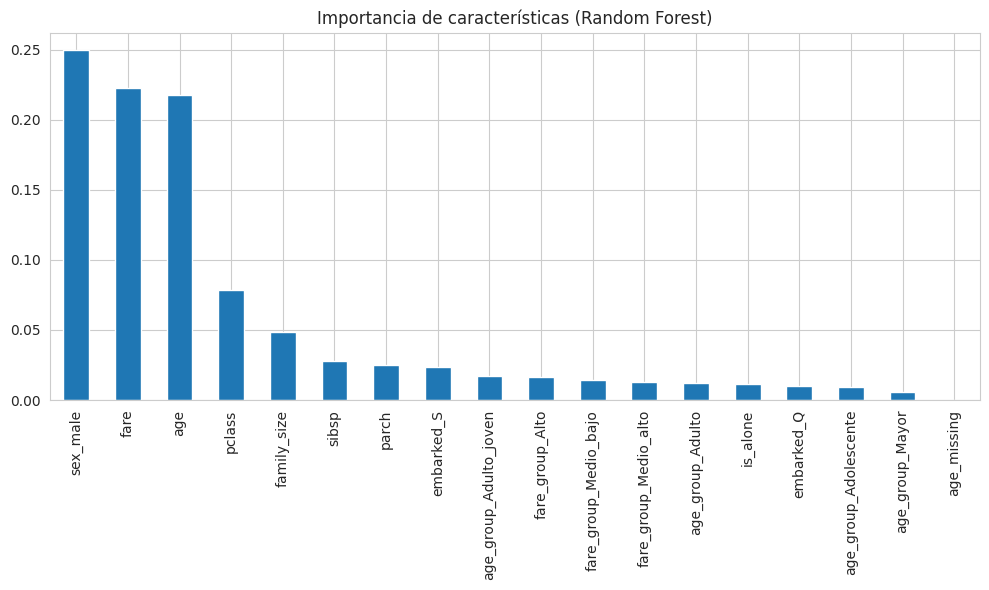

In [27]:
# Definimos X e y
X = df_encoded.drop(columns=['survived'])
y = df_encoded['survived']

# Entrenamos un Random Forest para obtener importancia
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title('Importancia de características (Random Forest)')
plt.tight_layout()
plt.show()

### 8.3. Selección con SelectKBest (chi2)
Nota: chi2 requiere características no negativas. Nuestras features escaladas tienen negativos, así que usaremos otro método o transformaremos.

In [28]:
# Usaremos información mutua (mutual_info_classif) que no requiere no negatividad
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_series.head(10)

,0
sex_male,0.175879
fare,0.126694
pclass,0.067553
parch,0.031490
embarked_S,0.025452
is_alone,0.019644
family_size,0.018065
sibsp,0.014709
fare_group_Alto,0.013711
fare_group_Medio_bajo,0.008013


## 9. PREPARACIÓN FINAL PARA MODELADO

Dividimos en entrenamiento y prueba, y creamos un pipeline que incluya las transformaciones.

In [31]:
# Separar features y target
columns_to_drop = ['survived', 'class', 'who', 'adult_male', 'alive', 'alone']

# Filter out columns that might not exist in df to prevent KeyError
actual_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

X = df.drop(columns=actual_columns_to_drop)
y = df['survived']

# Dividir en train y test (estratificado por y para mantener proporciones)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Tamaño train: {X_train.shape}')
print(f'Tamaño test: {X_test.shape}')

Tamaño train: (712, 12)
Tamaño test: (179, 12)


## 10. CONCLUSIONES

Hemos recorrido un flujo completo de EDA y feature engineering:
- Carga e inspección inicial
- Limpieza (nulos, duplicados, tipos, outliers)
- Análisis univariante y multivariante
- Creación de nuevas características (ingeniería)
- Codificación y escalado
- Selección de características
- Pipeline de preprocesamiento y modelado

Este arsenal de técnicas es aplicable a cualquier dataset. Recuerda siempre adaptar los pasos al contexto del problema y documentar cada decisión.